## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA

import numpy as np
import torch
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from os.path import join
import pandas as pd
np.random.seed(0)

data_path = '/home/lqr/CLIMA/datasets/section2/processed_data'

In [2]:
# # 读取encoded数据
# import zipfile
# with zipfile.ZipFile(join(data_path, 'autoencoder_csv.zip'), 'r') as zip_ref:
#     # for name in zip_ref.namelist():
#     #     print(name)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_normalized_downsampling_encoded.csv') as file:
#         data1 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data2 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_plus_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data3 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_times_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data4 = pd.read_csv(file, index_col=0)
# # 保存为npz文件
# np.savez(join(data_path, 'skin_normalized.npz'), gene=data1.values, peak=data2.values, gene_plus_peak=data3.values, gene_times_peak=data4.values)


In [3]:

# data_path = '/home/lqr/CLIMA/datasets/new_simu/encoded'
# data = np.load(join(data_path, 'skin_normalized.npz'))
data = np.load(join(data_path, 'data.npz'))
gene = np.squeeze(data['arr_0'], axis=0)
peak = np.squeeze(data['arr_1'], axis=0)
# gene = data['gene']
# peak = data['peak']
# gene_peak = data['gene_plus_peak']

In [4]:
# gene_peak = gene * peak
# gene_peak = gene + peak
# gene_peak = (gene + 1) * (peak + 1)

## Generate simulation data

In [16]:
print(f"gene_sum: {np.sum(gene)}")
print(f"peak_sum: {np.sum(peak)}")
# 找出所有值都为空的列
gene_empty_cols = np.all(gene == 0, axis=0)
peak_empty_cols = np.all(peak == 0, axis=0)
print(f"gene_empty_cols: {np.sum(gene_empty_cols)}")
print(f"peak_empty_cols: {np.sum(peak_empty_cols)}")

gene_sum: 0.0045928955078125
peak_sum: -0.925048828125
gene_empty_cols: 0
peak_empty_cols: 161568



Simulation parameters



Use simulation tool to generate multi-modality data

## Analyses based on single modality

Learn features from single modality

In [17]:
latent_dim = 100
view_gene_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene)
view_peak_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(peak)
# view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene_peak)

ValueError: Found array with dim 3. PCA expected <= 2.

In [7]:
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")
print(f"view_gene_feature.shape: {view_gene_feature.shape}")
print(f"view_peak_feature.shape: {view_peak_feature.shape}")

gene.shape: (1, 1289, 6025)
peak.shape: (1, 3366, 6025)


NameError: name 'view_gene_feature' is not defined

Perform clustering using PhenoGraph

In [9]:
view_a_label, _, _ = phenograph.cluster(view_gene_feature, random_state=42)
view_b_label, _, _ = phenograph.cluster(view_peak_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10173273086547852 seconds
Jaccard graph constructed in 0.3081691265106201 seconds
Wrote graph to binary file in 0.022484540939331055 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.793284
After 4 runs, maximum modularity is Q = 0.796237
Louvain completed 24 runs in 0.6766366958618164 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.2921888828277588 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09638381004333496 seconds
Jaccard graph constructed in 0.2538135051727295 seconds
Wrote graph to binary file in 0.017882823944091797 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.79875
After 11 runs, maximum modularity is Q = 0.800075
Louvain completed 31 runs in 0.89105224609375 seconds
Sorting communities by size, please wait .

In [10]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_gene_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_peak_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

X_embedded: (4531, 2)
label_true: (4531,)


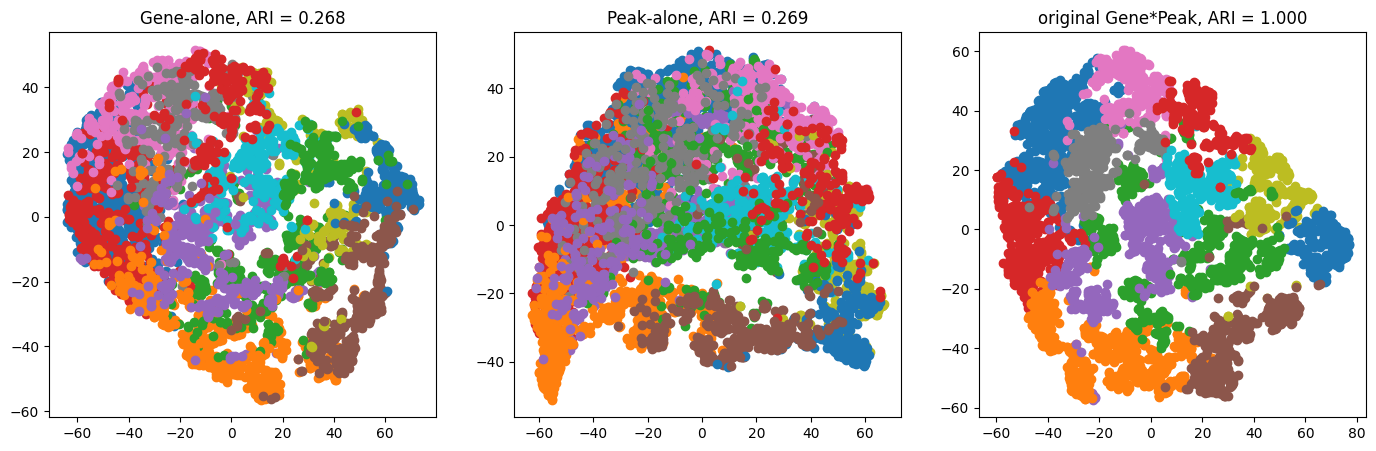

In [11]:
plt.figure(figsize=(17, 5))
# Gene-alone
plt.subplot(1, 3, 1)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {view_ab_label.shape}")
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Gene-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

# Peak-alone
plt.subplot(1, 3, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('Peak-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

# original Gene+Peak
plt.subplot(1, 3, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('original Gene*Peak, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [6]:
gene.shape

(1289, 6025)

Encoder: n_input: 6025, n_hidden: 128
Encoder: n_input: 6025, n_hidden: 128
++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
data_inputs_sc: (1289, 6025)
data_train_sc: (1289, 6025)
Encoder: x.shape: torch.Size([64, 6025])
Encoder: x.shape: torch.Size([64, 6025])
**************************************************
S: torch.Size([64, 100, 1])
G: torch.Size([64, 100, 1])


100%|██████████| 500/500 [00:01<00:00, 401.88it/s]


Epoch 500: Loss -0.6179438829421997
[[-5.293982  -1.838579  -3.615716  ... -4.742606  -5.974365  -2.0047107]
 [-4.677374  -5.2204623 -2.9620428 ... -1.2550738 -4.0934443 -4.126711 ]
 [-2.3235805 -3.1866841 -5.492757  ... -2.2502396 -3.4458368  5.8371434]
 ...
 [-0.2515729  4.9555917 -1.3628459 ...  5.3684034 -2.7978354 -3.6431293]
 [ 0.5479577 -3.7926395 -3.439039  ...  4.940139   4.119989  -4.0176725]
 [-6.944464  -1.913506  -2.2990384 ... -1.9541186 -3.1566248 -1.5729954]]
Encoder: x.shape: torch.Size([64, 6025])
Encoder: x.shape: torch.Size([64, 6025])
**************************************************
S: torch.Size([64, 100, 1])
G: torch.Size([64, 100, 1])


100%|██████████| 500/500 [00:01<00:00, 420.44it/s]


Epoch 500: Loss -0.6487842798233032
[[ 6.1904535 -2.221212   7.1781597 ... -4.9860578 -3.2712424 -1.7712271]
 [-3.12987   -5.245515  -2.2680745 ... -2.4984899 -2.4288044 -4.6635504]
 [-1.811882  -3.18284   -4.4850016 ...  5.9487085  7.3019824 -2.0745134]
 ...
 [ 1.6423556 -2.4545753  5.3537035 ... -3.885935  -3.2759764 -3.0278964]
 [-0.4688708  6.148217  -3.3894641 ...  5.586434   5.259012  -2.5344183]
 [ 6.28614   -4.0639424  6.0382724 ... -1.6743981 -4.1045127 -2.4256568]]
Encoder: x.shape: torch.Size([64, 6025])
Encoder: x.shape: torch.Size([64, 6025])
**************************************************
S: torch.Size([64, 100, 1])
G: torch.Size([64, 100, 1])


...

Epoch 500: Loss -1.494486927986145
[[ 2.9274993  -3.2110653  -3.3287969  ... -4.664666   -5.28874
  -4.733407  ]
 [ 6.448659   -3.056283   -2.0785573  ... -1.3084217  -1.8529357
  -3.5232391 ]
 [ 6.195627   -4.4453874  -5.213298   ... -4.165256   -3.362725
  -2.0627716 ]
 ...
 [ 5.5620728  -2.3564303  -3.991831   ... -4.053263   -2.489294
  -3.5924802 ]
 [ 4.6295195  -5.187564   -4.6232314  ... -3.089201   -1.9132009
  -2.826289  ]
 [ 0.46196368 -3.5028687  -3.1558254  ... -2.0441487  -5.377642
  -2.2772465 ]]
Encoder: x.shape: torch.Size([64, 6025])
Encoder: x.shape: torch.Size([64, 6025])
**************************************************
S: torch.Size([64, 100, 1])
G: torch.Size([64, 100, 1])


100%|██████████| 500/500 [00:01<00:00, 420.86it/s]


Epoch 500: Loss -1.626469373703003
[[-3.1567307  -1.748131   -2.1400096  ...  4.8498826  -4.466033
   4.911543  ]
 [-0.28393674 -1.1679121   3.1136568  ... -0.14674218  0.16294415
  -2.4166965 ]
 [-2.0934284  -3.4087942  -4.778197   ...  3.9127083  -3.084691
   4.4980907 ]
 ...
 [ 2.4327428   2.399427    0.70057774 ... -1.8927479   1.8606907
  -2.4687312 ]
 [-0.33599037 -3.8017812  -3.587797   ...  4.430843   -1.2273258
   3.3558617 ]
 [-4.7906885  -2.5125003  -2.5498838  ...  3.5187283  -5.0809903
   6.273691  ]]
outputs: torch.Size([64, 100])
Encoder: x.shape: torch.Size([1289, 6025])
Encoder: x.shape: torch.Size([3366, 6025])
**************************************************
S: torch.Size([1289, 100, 1])
G: torch.Size([3366, 100, 1])


  0%|          | 0/500 [00:00<?, ?it/s]


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

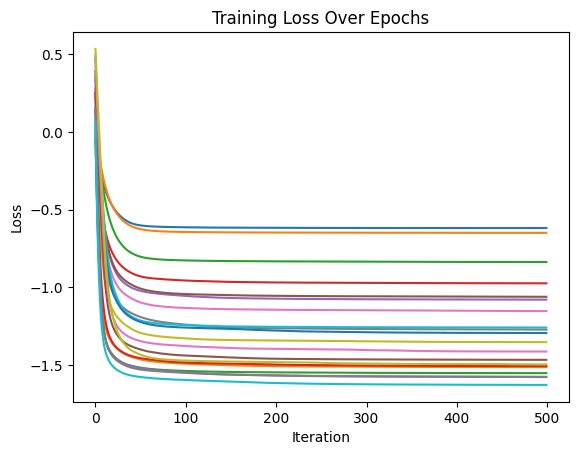

In [5]:
outputs = muse.dual_muse_fit_predict(
    [gene],
    [peak],
    [],
    [],
    # [view_a_label, view_b_label],
    # [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=0,
)

In [13]:
latent_sc = (outputs[0])
latent_st = (outputs[1])
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (4531, 100)
latent_st: (4531, 100)
reconstruct_sc: (2, 4531, 1024)
reconstruct_st: (1, 4531, 1024)
encoded_sc: (2, 4531, 128)
encoded_st: (1, 4531, 128)


## Perform clustering
PhenoGraph clustering

In [14]:
latent_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
latent_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0921330451965332 seconds


Jaccard graph constructed in 0.4571099281311035 seconds
Wrote graph to binary file in 0.017485380172729492 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.625527
After 14 runs, maximum modularity is Q = 0.627831
Louvain completed 34 runs in 1.699591875076294 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.6490750312805176 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09500479698181152 seconds
Jaccard graph constructed in 0.4483458995819092 seconds
Wrote graph to binary file in 0.0176393985748291 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.633773
After 2 runs, maximum modularity is Q = 0.639571
After 3 runs, maximum modularity is Q = 0.64564
Louvain completed 23 runs in 1.2386832237243652 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.1875784397125244 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [15]:
latent_X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
latent_Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

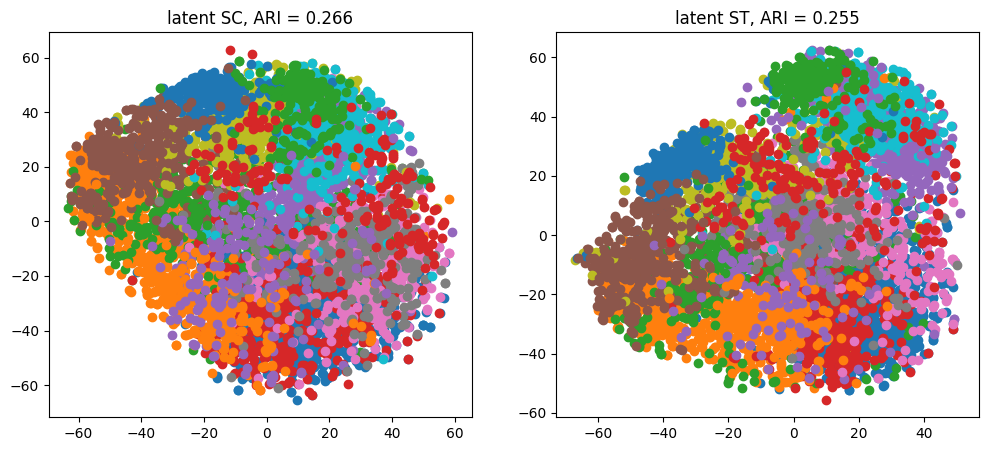

In [16]:
plt.figure(figsize=(12, 5))
# Gene, Peak MUSE(latent sc)
plt.subplot(1, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(latent_X_embedded[idx, 0], latent_X_embedded[idx, 1])
    plt.title('latent SC, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_sc))

# Peak+Gene MUSE(latent st)
plt.subplot(1, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(latent_Y_embedded[idx, 0], latent_Y_embedded[idx, 1])
    plt.title('latent ST, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_st))

plt.show()

In [17]:
print('[gene, peak] and [gene+peak] ARI: ', adjusted_rand_score(latent_label_sc, latent_label_st))

[gene, peak] and [gene+peak] ARI:  0.5482565574044264


In [18]:
# PCA降维
latent_sc = PCA(n_components=100, random_state=42).fit_transform(all_gene[2500:, :])
latent_st = PCA(n_components=100, random_state=42).fit_transform(all_peak[2500:, :])
# 训练的输出
# latent_sc = outputs[0]
# latent_st = outputs[1]
# 未训练
# latent_sc = gene
# latent_st = peak
# 预测的输出
# latent_sc = out[0][0].cpu().numpy()
# latent_st = out[0][1].cpu().numpy()

In [43]:
from sim_tangram.train_tangram import read_csv_and_run_tangram
import torch

# tangram
tangram_sim, _ = read_csv_and_run_tangram(
    [torch.tensor(gene, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(peak, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=50,
    lambda_g1=1,
    lambda_g2=1
)

/tmp/ipykernel_369555/168996550.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  [torch.tensor(gene, device='cuda:0', dtype=torch.float32)],
/tmp/ipykernel_369555/168996550.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  [torch.tensor(peak, device='cuda:0', dtype=torch.float32)],


**************************************************
S: torch.Size([1289, 6025, 1])
G: torch.Size([3366, 6025, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

 10%|█         | 50/500 [00:19<03:03,  2.46it/s]

Epoch 50: Loss nan


...

 60%|██████    | 300/500 [01:59<01:20,  2.48it/s]

Epoch 300: Loss nan


 62%|██████▏   | 312/500 [02:04<01:15,  2.50it/s]


KeyboardInterrupt: 

: 

**************************************************
S: torch.Size([4531, 1024, 1])
G: torch.Size([4531, 1024, 1])


100%|██████████| 500/500 [00:03<00:00, 144.42it/s]

Epoch 500: Loss -1.8306206464767456
[[ 0.32818496  3.0366092   1.9881977  ... -0.5634064   1.9784583
  -0.9994797 ]
 [-0.805753   -0.2794458   0.2230945  ...  0.3532936   0.51847714
   0.04773582]
 [-0.4928891   0.30868524  1.43215    ...  1.3833542  -0.3595684
  -0.7185888 ]
 ...
 [-0.26017404  0.6025194   0.363446   ... -2.7887177   1.0841328
  -0.81293446]
 [-1.5553186  -1.0419893  -1.5380753  ... -0.19835144  0.7799457
   2.441488  ]
 [-0.8884155  -1.9517419  -0.527778   ... -1.0256152   4.0095463
   1.7967511 ]]


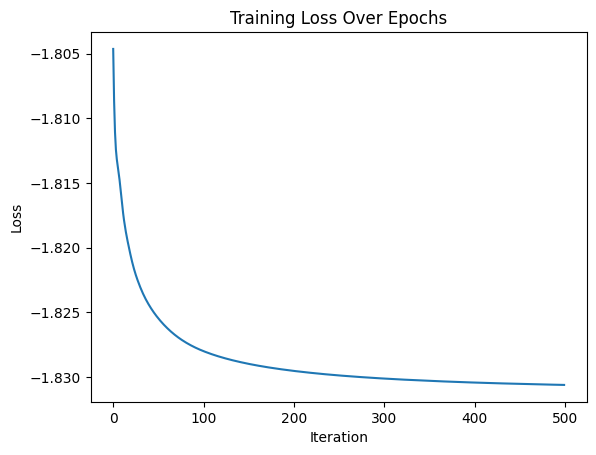

In [29]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(gene, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(peak, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [32]:
# tangram cosine_similarity
cos_tg_mapping = cos_sim_tg.argmax(axis=1)

# # org tangram cca
# org_cca_mapping = cca_sim.argmax(axis=1)
# tangram cca
mapping = tangram_sim.argmax(axis=1)
for i in range(len(mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {mapping[i]:4d}", end="\t")

# cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(gene, peak)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")



 0:  433	 1: 1691	 2: 3095	 3:  458	 4: 3962	
 5: 3775	 6: 1030	 7: 3206	 8: 3624	 9:  529	
10:   10	11: 2733	12: 4306	13:  807	14:  290	
15: 2718	16: 3403	17:  124	18: 1481	19: 2130	
20: 1580	21:  342	22: 1314	23: 3564	24:   12	
25:  132	26: 1920	27:  210	28:  931	29: 2495	
 0: 1551	 1: 1551	 2: 4340	 3: 1950	 4: 1551	
 5: 4340	 6: 1959	 7: 1959	 8: 3344	 9: 1959	
10: 2386	11: 1950	12: 2678	13: 1651	14:  860	
15: 1950	16: 1551	17: 1551	18: 1959	19: 1959	
20: 1959	21: 1594	22: 2061	23: 2061	24: 2061	
25: 2386	26: 1959	27: 2386	28: 1551	29: 2386	

In [33]:
sample_size = tangram_sim.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
tangram_acc = np.sum(mapping == gt) / sample_size
print("tangram cca accuracy:", tangram_acc)
# cca_acc = np.sum(org_cca_mapping == gt) / sample_size
# print("org tangram cca accuracy:", cca_acc)
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 0.00022070183182520416
tangram cca accuracy: 0.0022070183182520413
cos_tg accuracy: 0.0024277201500772457


In [24]:
model = outputs[6]

In [25]:
print(view_a_label.shape)
print(view_ab_label.shape)
print(all_gene.shape)
print(all_peak.shape)


(4531,)
(4531,)
(4531, 1024)
(4531, 1024)


In [26]:
from multi_muse_sc import *

with torch.no_grad():
    data_inputs_tensor_sc = get_all_tensor(
        [all_gene[2500:], all_peak[2500:]]
    )
    data_inputs_tensor_st = get_all_tensor(
        [all_gene[2500:] + all_peak[2500:]]
    )
    out = model(
        data_inputs_tensor_sc,
        data_inputs_tensor_st,
        info_nce_lambda=1,
    )